# LSTM Stock Price Prediction

- LSTM -> Long Short Term Memory

## Requirements

In [169]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset
import seaborn as sns
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler


## Tutorials
- **(Greg Hogg, 2023)** Video: https://www.youtube.com/watch?v=q_HS4s1L8UI&t=147s
- **(NeuralNine, 2025)** Video: https://www.youtube.com/watch?v=IJ50ew8wi-0

## Load Data

In [170]:
df = pd.read_csv('../data/combined_output.csv')

df.head()

,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,...,3_day_max,3_day_min,5_day_max,5_day_min,day_of_week,numerical_sentiment,mean_sentiment_probability,percent_positive,percent_negative,percent_neutral
0,2026-01-26,672.36,675.2800,661.2855,665.125,16327378,671.797893,674.715452,660.732652,664.568942,...,675.2800,661.2855,675.2800,644.4450,1,-0.082474,0.797085,0.134021,0.216495,0.649485
1,2026-01-27,672.97,676.8150,664.6600,674.590,13148719,672.407383,676.249169,664.104331,674.026029,...,676.8150,661.2855,676.8150,644.4450,2,0.158879,0.790941,0.299065,0.140187,0.560748
2,2026-01-28,668.73,677.6775,666.1000,674.500,25709600,668.170928,677.110948,665.543127,673.936104,...,677.6775,661.2855,677.6775,661.2855,3,0.170543,0.801010,0.302326,0.131783,0.565891
3,2026-01-29,738.31,744.0000,712.5500,737.430,59852903,737.692758,743.378001,711.954294,736.813493,...,744.0000,664.6600,744.0000,661.2855,4,-0.027027,0.806134,0.209459,0.236486,0.554054
4,2026-01-30,716.50,732.1700,713.5900,727.500,23744573,715.900991,731.557891,712.993424,726.891795,...,744.0000,666.1000,744.0000,661.2855,5,-0.109375,0.837781,0.156250,0.265625,0.578125


## Check Device

In [171]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu:1'

device

'cpu:1'

## Lag Features

In [172]:
columns = df.columns

day = 1

df = df.set_index('date')

df['previous_day_numerical_sentiment'] = df['numerical_sentiment'].shift(day)
df['previous_day_mean_sentiment_probability'] = df['mean_sentiment_probability'].shift(day)
df['previous_day_percent_positive'] = df['percent_positive'].shift(day)
df['previous_day_percent_negative'] = df['percent_negative'].shift(day)
df['previous_day_percent_neutral'] = df['percent_neutral'].shift(day)

df = df.drop(columns=['high',
                      'low',
                      'open',
                      'volume',
                      'adjClose',
                      'adjHigh',
                      'adjLow',
                      'adjOpen',
                      'adjVolume',
                      'divCash',
                      'splitFactor',
                      'numerical_sentiment',
                      'mean_sentiment_probability',
                      'percent_positive',
                      'percent_negative',
                      'percent_neutral',])

df.iloc[2]

close                                      6.687300e+02
previous_day_close                         6.729700e+02
previous_day_high                          6.768150e+02
previous_day_low                           6.646600e+02
previous_day_open                          6.745900e+02
previous_day_volume                        1.314872e+07
1_day_max                                  6.776775e+02
1_day_min                                  6.661000e+02
3_day_max                                  6.776775e+02
3_day_min                                  6.612855e+02
5_day_max                                  6.776775e+02
5_day_min                                  6.612855e+02
day_of_week                                3.000000e+00
previous_day_numerical_sentiment           1.588785e-01
previous_day_mean_sentiment_probability    7.909406e-01
previous_day_percent_positive              2.990654e-01
previous_day_percent_negative              1.401869e-01
previous_day_percent_neutral               5.607

## Plot

[Text(0.5, 0, 'Date'), Text(0, 0.5, 'Closing Price')]

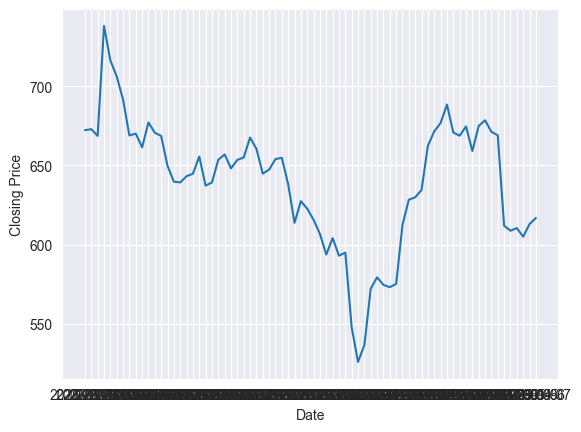

In [173]:
line_graph = sns.lineplot(x='date', y='close', data=df)
line_graph.set(xlabel='Date', ylabel='Closing Price')

## Remove Rows With Nulls

In [174]:
df = df.dropna()

## Scale Data

In [175]:
scalar_x = StandardScaler()
scalar_y = StandardScaler()

X_df = df.iloc[:,1:]
Y_df = df.iloc[:, [0]]

train_size = int(len(df) * 0.8)

X_train_df_as_numpy = scalar_x.fit_transform(X_df[:train_size]) # Fit to training data
X_test_df_as_numpy = scalar_x.transform(X_df[train_size:])
Y_train_df_as_numpy = scalar_y.fit_transform(Y_df[:train_size]) # Don't fit to test data as it will cause data leakage
Y_test_df_as_numpy = scalar_y.transform(Y_df[train_size:])


X_train_df_as_numpy

array([[ 8.40068418e-01,  6.98689838e-01,  8.03917154e-01,
         6.58439125e-01,  1.09234834e-02,  7.33460072e-01,
         8.80267048e-01,  5.76616283e-01,  1.04465975e+00,
         4.86243756e-01,  7.04197911e-01, -7.33799386e-01,
        -4.18998177e-01, -4.64784010e-01, -7.88689017e-01,
        -1.81109994e-03,  5.98378244e-01],
       [ 8.54495414e-01,  7.34946104e-01,  8.85199873e-01,
         8.83821129e-01, -3.61709439e-01,  7.53817758e-01,
         9.14868214e-01,  5.97527356e-01,  1.04465975e+00,
         5.07297319e-01,  1.10567618e+00,  0.00000000e+00,
         1.34954678e+00, -7.72155981e-01,  1.48108360e+00,
        -8.22547497e-01, -3.24790989e-01],
       [ 7.54215968e-01,  7.55318110e-01,  9.19885639e-01,
         8.81678035e-01,  1.11079761e+00,  2.31923530e+00,
         2.03099610e+00,  2.20549790e+00,  1.12723758e+00,
         2.12622475e+00,  1.10567618e+00,  7.33799386e-01,
         1.43501728e+00, -2.68425001e-01,  1.52591884e+00,
        -9.12937110e-01, -2.7

## Split Data Train/Test

In [176]:
X_train = X_train_df_as_numpy.reshape((-1, 17, 1))
Y_train = Y_train_df_as_numpy.reshape((-1, 1))

X_test = X_test_df_as_numpy.reshape((-1, 17, 1))
Y_test = Y_train_df_as_numpy.reshape((-1, 1))

X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((56, 17, 1), (56, 1), (15, 17, 1), (56, 1))

## Convert To Tensors

In [177]:
X_train = torch.tensor(X_train).float()
Y_train = torch.tensor(Y_train).float()
X_test = torch.tensor(X_test).float()
Y_test = torch.tensor(Y_test).float()

X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

(torch.Size([56, 17, 1]),
 torch.Size([56, 1]),
 torch.Size([15, 17, 1]),
 torch.Size([56, 1]))

## Dataset Class

In [178]:
class StockDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [179]:
train_dataset = StockDataset(X_train, Y_train)
test_dataset = StockDataset(X_test, Y_test)

train_dataset.__len__()

56

## Dataloaders

In [180]:
train_dataloader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=False,
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
)

train_dataloader

In [181]:
for _, batch in enumerate(train_dataloader):
    x_batch, y_batch = batch[0].to(device), batch[1].to(device)
    print(x_batch.shape, y_batch.shape)


torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])


## Define Neural Network

In [182]:
class Net(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        batch_size = x.shape[0]
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

In [183]:
model = Net(1, 32, 2, 1)
model.to(device)
model

Net(
  (lstm): LSTM(1, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

## Training Loop

In [184]:
lr = 1e-3
num_epochs = 300
loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

for epoch in range(num_epochs):
    optimizer.zero_grad()
    output = model(X_train)
    loss = loss_function(output, Y_train)

    if epoch % 25 == 0:
        # Every 25 epochs
        print(epoch, loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()



0 1.0047768354415894
25 0.7057641744613647
50 0.19035856425762177
75 0.1552022397518158
100 0.12740513682365417
125 0.11244156211614609
150 0.10623012483119965
175 0.10284673422574997
200 0.10006504505872726
225 0.09698092192411423
250 0.09309755265712738
275 0.08783919364213943


## Testing

In [186]:
model.eval()

test_output_prediction = model(X_test)

train_output_prediction = scalar_y.inverse_transform(output.detach().cpu().numpy())
train_actual = scalar_y.inverse_transform(Y_train.detach().cpu().numpy())
test_output_prediction = scalar_y.inverse_transform(test_output_prediction.detach().cpu().numpy())
test_actual = scalar_y.inverse_transform(Y_test.detach().cpu().numpy())

train_output_prediction

array([[665.2515 ],
       [667.8507 ],
       [707.4563 ],
       [724.25696],
       [715.1184 ],
       [697.65063],
       [681.80994],
       [675.9013 ],
       [671.16266],
       [663.46387],
       [666.4518 ],
       [666.322  ],
       [665.16595],
       [659.9661 ],
       [641.7508 ],
       [641.229  ],
       [645.11804],
       [650.6554 ],
       [649.46106],
       [644.98047],
       [645.16364],
       [652.17694],
       [652.6505 ],
       [648.9398 ],
       [648.0658 ],
       [656.1078 ],
       [660.2782 ],
       [658.74133],
       [639.27325],
       [647.12787],
       [652.6308 ],
       [652.2763 ],
       [634.176  ],
       [627.7111 ],
       [630.84326],
       [623.69037],
       [616.8863 ],
       [605.2231 ],
       [587.6842 ],
       [593.6284 ],
       [595.1757 ],
       [570.78564],
       [559.2863 ],
       [548.549  ],
       [549.69904],
       [567.99347],
       [570.60895],
       [563.09393],
       [567.75867],
       [595.0319 ],
